In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import contextlib
import io

from dataset.dataset_builder import SpectralDatasetBuilder
from dataset.data_classes import PytorchSpectraDataset

from models.cdiff_lightning import LitCfgDiffusion

from utils.utils import encode_labels, load_config
from tools.calculation_functions import compute_authenticity, compute_mmd, frechet_distance, within_condition_icc, within_condition_distribution_distance

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cdiff = LitCfgDiffusion.load_from_checkpoint("../pretrained_models/weights_cdiff.ckpt")
cdiff.to(device)
cdiff.eval();

cfg = load_config('../config.yaml')
continous_conditions = cfg["condition_labels"]["continuous"]
categorical_conditions = cfg["condition_labels"]["categorical"]
conditions = categorical_conditions + continous_conditions

In [3]:
dataset_builder = SpectralDatasetBuilder(data_path='../data/in-silico-gen-data.parquet', data_split={"train": 0.8, "test": 0.2}, config_path='../config.yaml')
dataset = PytorchSpectraDataset("../data/h4h_raw_2024-09-16_with_subject_ids.parquet")

X_real = dataset.df_val_scaled
y_real = X_real[conditions]
bmi_age = y_real[['bmi', 'age']]
bmi_age = dataset_builder.minmax_scaler.inverse_transform(bmi_age).T
bmi = bmi_age[0]
age = bmi_age[1]
sex = y_real['sex'].map({0: 'male', 1:'female'}).values
features = np.array(dataset_builder.features).astype(float)

X_real.columns = np.hstack([features, X_real.columns.values[519:]])

y_df = pd.DataFrame({
    "sex": sex,
    "bmi": bmi,
    "age": age
})

y = y_df.to_dict(orient="records")

In [4]:
labels = y_df.copy()
labels['sex'] = labels['sex'].map({'male': 0, 'female':1})

labels.loc[labels.age <= 52, "age"] = 0
labels.loc[labels.bmi <= 27, "bmi"] = 0

labels.loc[labels.age > 52, "age"] = 1
labels.loc[labels.bmi > 27, "bmi"] = 1

In [5]:
condition_dict = {
    col: torch.tensor(y_real[col].values, device=device, dtype=torch.float32).unsqueeze(1)
    for col in conditions
}

In [25]:
guidance_scales = np.linspace(0,3, 25)

In [26]:
icc_real = within_condition_icc(X_real[features].values, labels)

In [27]:
metrics = {
    'fre': [],
    'icc': [],
}

corr_sex_real = X_real[features].corrwith(X_real['sex'])
corr_bmi_real = X_real[features].corrwith(X_real['bmi'])
corr_age_real = X_real[features].corrwith(X_real['age'])

for guidance_scale in guidance_scales:
    print(f'now calculating with gamma={guidance_scale}')
    X_sim = cdiff.generate_with_condition_dict(condition_dict, sampling_method='ddpm', guidance_scale=guidance_scale, eta=1, n_steps=64, inference_timestep_truncation=None)
    X_sim = pd.DataFrame(X_sim.cpu().numpy(), columns=features)
    X_sim[conditions] = pd.DataFrame(y)

    metrics['fre'].append(within_condition_distribution_distance(X_real[features].values, X_sim[features].values, labels))
    metrics['icc'].append(within_condition_icc(X_sim[features].values, labels))

now calculating with gamma=0.0
now calculating with gamma=0.125
now calculating with gamma=0.25
now calculating with gamma=0.375
now calculating with gamma=0.5
now calculating with gamma=0.625
now calculating with gamma=0.75
now calculating with gamma=0.875
now calculating with gamma=1.0
now calculating with gamma=1.125
now calculating with gamma=1.25
now calculating with gamma=1.375
now calculating with gamma=1.5
now calculating with gamma=1.625
now calculating with gamma=1.75
now calculating with gamma=1.875
now calculating with gamma=2.0
now calculating with gamma=2.125
now calculating with gamma=2.25
now calculating with gamma=2.375
now calculating with gamma=2.5
now calculating with gamma=2.625
now calculating with gamma=2.75
now calculating with gamma=2.875
now calculating with gamma=3.0


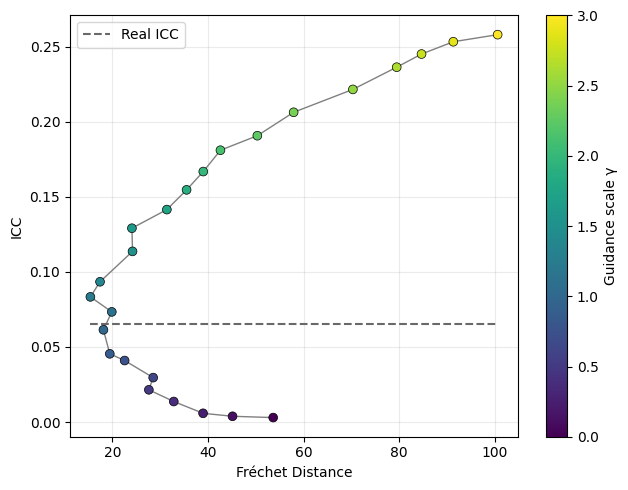

In [29]:
fre = np.array(metrics["fre"])
icc = np.array(metrics["icc"])

fig, ax = plt.subplots(figsize=(6.5,5.))

# scatter with color encoding gamma
sc = ax.scatter(
    fre,
    icc,
    c=guidance_scales,
    cmap="viridis",
    s=40,
    edgecolor="black",
    linewidth=0.5,
    zorder=3
)

# connect trajectory
ax.plot(fre, icc, color="gray", linewidth=1)

# real ICC reference
ax.hlines(
    icc_real,
    fre.min(),
    fre.max(),
    linestyle="dashed",
    color="dimgrey",
    linewidth=1.5,
    label="Real ICC"
)

# colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Guidance scale γ")

# labels
ax.set_xlabel("Fréchet Distance")
ax.set_ylabel("ICC")

# small polishing
ax.grid(alpha=0.25)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('CDIFF_gamma_tuning.pdf', dpi=300)
plt.show()

# DDIM eta and n_steps fitting

In [22]:
etas = np.linspace(0,1,11)
steps = np.linspace(32, 128, 11).astype(int)
errs = pd.DataFrame()

for eta in etas:
    for step in steps:
        X = cdiff.generate_with_condition_dict(condition_dict, sampling_method='ddim', guidance_scale=1.1, eta=eta, n_steps=step)
        X = X.cpu().numpy()
        err = np.mean((np.var(X, axis=0) - 1)**2)
        errs.loc[str(eta), str(step)] = err

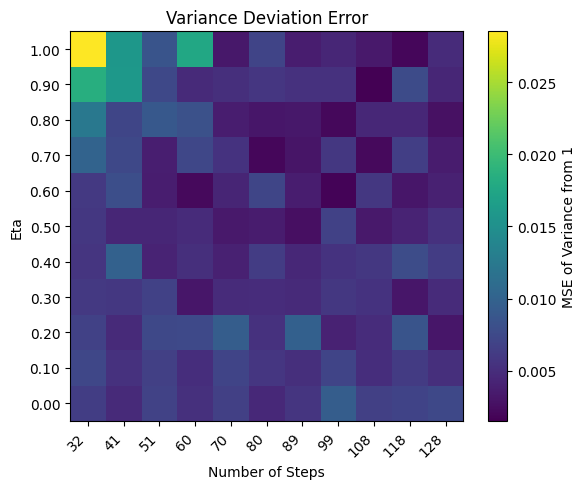

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    errs.values,
    origin='lower',
    aspect='auto'
)

# Axis ticks mapped to actual parameter values
ax.set_xticks(np.arange(len(steps)))
ax.set_yticks(np.arange(len(etas)))

ax.set_xticklabels(steps)
ax.set_yticklabels([f"{e:.2f}" for e in etas])

ax.set_xlabel("Number of Steps")
ax.set_ylabel("Eta")
ax.set_title("Variance Deviation Error")

# Rotate x labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Colorbar with label
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("MSE of Variance from 1")

plt.tight_layout()
plt.show()

In [24]:
errs

,32,41,51,60,70,80,89,99,108,118,128
0.0,0.006465,0.004688,0.006889,0.005306,0.006623,0.004647,0.005684,0.009520,0.006604,0.006999,0.007388
0.1,0.007283,0.005410,0.006644,0.005027,0.007108,0.005799,0.005189,0.007055,0.005105,0.006258,0.005146
0.2,0.006695,0.004761,0.007385,0.007450,0.009460,0.005332,0.009753,0.004105,0.004980,0.008488,0.003155
0.30000000000000004,0.005978,0.005849,0.006699,0.003176,0.004856,0.004958,0.004702,0.005847,0.005486,0.003118,0.004813
0.4,0.005702,0.009914,0.004171,0.005190,0.003986,0.006286,0.004495,0.005498,0.005919,0.007752,0.006322
0.5,0.005945,0.004382,0.004372,0.004794,0.003372,0.003574,0.002626,0.006698,0.003363,0.004174,0.005403
0.6000000000000001,0.006056,0.008037,0.003648,0.002239,0.004369,0.007128,0.003647,0.001762,0.005921,0.003188,0.003970
0.7000000000000001,0.010090,0.007358,0.003764,0.007297,0.005454,0.002026,0.003095,0.005861,0.002234,0.006551,0.003585
0.8,0.012374,0.007216,0.008967,0.008251,0.003662,0.003148,0.003311,0.002086,0.004513,0.004477,0.002700
0.9,0.018405,0.015878,0.007380,0.004706,0.005161,0.005813,0.005363,0.005326,0.001524,0.007645,0.004408


In [17]:
errs.min()


32     0.004844
41     0.004404
51     0.006317
60     0.006386
70     0.004849
80     0.004322
89     0.002987
99     0.004627
108    0.003733
118    0.004149
128    0.004844
dtype: float32

In [18]:
X = cdiff.generate_with_condition_dict(condition_dict, sampling_method='ddpm', guidance_scale=0, eta=eta, n_steps=step)
X = X.cpu().numpy()
err = np.mean((np.var(X, axis=0) - 1)**2)

In [19]:
err

np.float32(0.015067746)